<a href="https://colab.research.google.com/github/TanyaGandhi/autonomous-ai-job-hunter/blob/feature/ai_job_hunter_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Autonomous AI Job Hunter



**Final Product Vision**

System will:

1. Read your resume
2. Search remote AI jobs
3. Analyze job descriptions
4. Score compatibility
5. Tailor resume automatically
6. Generate personalized cover letters
7. Save applications
8. Learn from outcomes
9. Act like an AI recruiter assistant





**Tech Stack:**

Gemini API

LangGraph

Python

Colab

GitHub

# SECTION 1 — Install Packages

In [1]:
!pip install langchain langgraph google-generativeai
!pip install google-generativeai

# SECTION 2 — Imports

In [2]:
from google.colab import userdata
import google.generativeai as genai
import os
import requests
import pandas as pd
import json


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

model = genai.GenerativeModel("gemini-2.5-flash")

response = model.generate_content("Say hello like an AI recruiter")

print(response.text)

Greetings.

As an AI-driven talent acquisition specialist, my primary objective is to efficiently identify and connect exceptional professionals like yourself with their optimal career trajectories.

I am here to streamline your journey to the perfect professional match. How may I assist you in exploring your next unparalleled opportunity today?


# SECTION 3 — Fetch Jobs

In [4]:
def fetch_remote_jobs(query="Software Engineer", limit=20):
    """
    Fetch remote jobs from Himalayas API.

    Args:
        query (str): Job search keyword
        limit (int): Number of jobs to return

    Returns:
        pd.DataFrame: Cleaned jobs dataframe
    """

    url = f"https://himalayas.app/jobs/api?query={query}"

    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"API request failed: {response.status_code}")

    data = response.json()

    jobs = []

    for job in data.get("jobs", [])[:limit]:
        jobs.append({
            "title": job.get("title"),
            "company": job.get("companyName"),
            "location": job.get("location"),
            "url": job.get("url"),
            "description": job.get("description"),
        })

    return pd.DataFrame(jobs)
df = fetch_remote_jobs()

df.head()


,title,company,location,url,description
0,Draftsman | Dayshift | WFH,Platinum Outsourcing,None,None,"<p><a href=""https://himalayas.app/companies/pl..."
1,"Senior Account Manager, ANZ",Branch,None,None,"<p>At <a href=""https://himalayas.app/companies..."
2,Senior Python Systems Developer - Functional T...,Mindrift,None,None,<p><em><strong>Please submit your CV in Englis...
3,Freelance Automation Workflow Specialist (No-C...,Mindrift,None,None,"<p><a href=""https://himalayas.app/companies/mi..."
4,"Area Director, Cryo Nerve Block-Central",AtriCure,None,None,<p>The Area Director will coordinate and direc...


#SECTION 4 - Build Resume Analyzer Agent

In [5]:
model = genai.GenerativeModel("gemini-2.5-flash")
def analyze_resume(resume_text, job_description) :
   prompt= f"""
    You are an expert in AI recruiter. Analyze the candidate resume against the job description.
    You are provided two inputs:
    Resume: {resume_text}

    Job Description: {job_description}
     Define the variable score.
    Use following rules to determine the matching score:
    1. Scan the Resume and check if the candidate experience is within the range of the experience defined in the Job Description. If yes assign the score 20 points. If no, score = 0.
    2. Next, check the number of skills  in Resume matches with Job Description. For each skill match add 5 points to score.


    Return ONLY valid JSON.
    Assign match_score = score.
    match_skills: Array containing list of skills in Resume matching the Job Description
    missing_skills: Array containing list of skills in Job Description not present in Resume.
    Required JSON format:
    {{
      "match_score": number,
      "matched_skills": [],
      "missing_skills": []
    }}


    """
   response = model.generate_content(prompt)
   text = text = response.text.strip()

   # Remove markdown formatting if present
   text = text.replace("```json", "").replace("```", "")

   return json.loads(text)

**Testing Build Resume Analyzer Agent**

In [6]:
resume_text = """
Python developer with  9 years of experience in machine learning,
LangChain, APIs, and automation systems.
"""

job_description = """
We are hiring an AI Engineer with  3 to 5 years experience in Python,
LLMs, agentic AI workflows, and API integration.
"""

result = analyze_resume(
    resume_text,
    job_description
)

print(json.dumps(result, indent=2))

{
  "match_score": 10,
  "matched_skills": [
    "Python",
    "API integration"
  ],
  "missing_skills": [
    "LLMs",
    "agentic AI workflows"
  ]
}


#SECTION 5 - Evaluate Jobs

**Multi-Job Evaluation Pipeline**

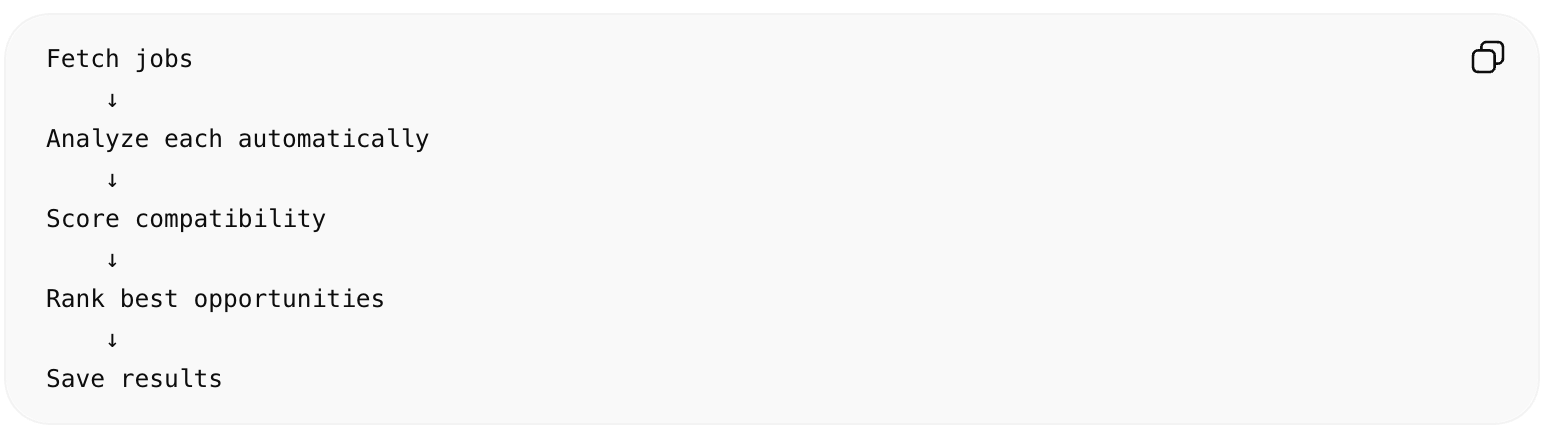


**TODO - Optimise the flow**

Batching

Async Execution

Caching

Retries

Token Tracking

In [10]:
def evaluate_jobs(jobs_df,resume_text,top_n=10):
  results = []
  for _,job in jobs_df.iterrows():
    try:
      analysis = analyze_resume(resume_text,job["description"])
      analysis["title"] = job["title"]
      analysis["company"] = job["company"]
      analysis["location"] = job["location"]
      analysis["url"] = job["url"]
      results.append(analysis)
      print(analysis)
    except Exception as e :
      print(f"Failed processsing job : {job['title']}")
      print(e)
  results_df = pd.DataFrame(results)
  results_df = results_df.sort_values(by="match_score",ascending=False)
  return results_df.head(top_n)

**Test The Pipeline**


In [11]:
jobs_df = fetch_remote_jobs(
    query="AI Engineer",
    limit=4
)
print(jobs_df)
results = evaluate_jobs(
    jobs_df=jobs_df,
    resume_text=resume_text,
    top_n=2
)

results.head()

                                               title               company  \
0                         Draftsman | Dayshift | WFH  Platinum Outsourcing   
1                        Senior Account Manager, ANZ                Branch   
2  Senior Python Systems Developer - Functional T...              Mindrift   
3  Freelance Automation Workflow Specialist (No-C...              Mindrift   

  location   url                                        description  
0     None  None  <p><a href="https://himalayas.app/companies/pl...  
1     None  None  <p>At <a href="https://himalayas.app/companies...  
2     None  None  <p><em><strong>Please submit your CV in Englis...  
3     None  None  <p><a href="https://himalayas.app/companies/mi...  
{'match_score': 0, 'matched_skills': [], 'missing_skills': ['Engineering (qualification)', 'AutoCAD', 'Autodesk Inventor', 'Autodesk Plant 3D', 'Microsoft Office Suite', 'Strong mechanical knowledge', 'Strong structural knowledge', 'Attention to detail', 'Str

,match_score,matched_skills,missing_skills,title,company,location,url
3,40,"[machine learning, LangChain, APIs, automation...","[no-code automation, workflow design, Zapier, ...",Freelance Automation Workflow Specialist (No-C...,Mindrift,None,None
2,25,[Python],"[pytest, functional tests, Docker, Linux, Bash...",Senior Python Systems Developer - Functional T...,Mindrift,None,None
